In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
sns.set_style("whitegrid")

print("All libraries loaded.")

All libraries loaded.


In [2]:
from src.data.loader import BookCrossingLoader
from src.data.preprocessor import BookCrossingPreprocessor

loader = BookCrossingLoader("../data/raw")
raw = loader.load_all(verbose=False)

prep = BookCrossingPreprocessor()
clean = prep.fit_transform(raw)

users   = clean.users
books   = clean.books
ratings = clean.ratings

print(f"Users:   {len(users):,}")
print(f"Books:   {len(books):,}")
print(f"Ratings: {len(ratings):,}")

Users:   278,859
Books:   271,378
Ratings: 1,149,753


In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

# Combine title + author into one text field per book
# This is the "content" signal — what the book is about textually
books['content'] = (
    books['title'].fillna('') + ' ' +
    books['author'].fillna('')
).str.lower().str.strip()

print("Sample content fields:")
print(books['content'].head(10).to_string())
print()

# TF-IDF vectorizer
# max_features=10000 keeps it fast on CPU
# ngram_range=(1,2) captures both single words and two-word phrases
#   e.g. "harry potter" as one feature, not just "harry" and "potter"
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,            # ignore terms that appear in fewer than 2 books
    sublinear_tf=True,   # dampen effect of very frequent terms
    strip_accents='unicode',
    analyzer='word',
)

tfidf_matrix = tfidf.fit_transform(books['content'])
print(f"TF-IDF matrix shape: {tfidf_matrix.shape}")
print(f"  Rows: {tfidf_matrix.shape[0]:,} books")
print(f"  Cols: {tfidf_matrix.shape[1]:,} vocabulary features")
print(f"  Sparsity: {(1 - tfidf_matrix.nnz / (tfidf_matrix.shape[0] * tfidf_matrix.shape[1])):.4%}")

# Build isbn → row index map for the books table
isbn_to_book_idx = {isbn: idx for idx, isbn in enumerate(books['isbn'])}
print(f"\nBuilt ISBN → book index map for {len(isbn_to_book_idx):,} books")

Sample content fields:
0               classical mythology mark p. o. morford
1                    clara callan richard bruce wright
2                    decision in normandy carlo d'este
3    flu: the story of the great influenza pandemic...
4               the mummies of urumchi e. j. w. barber
5                       the kitchen god's wife amy tan
6    what if?: the world's foremost military histor...
7                          pleading guilty scott turow
8    under the black flag: the romance and the real...
9    where you'll find me: and other stories ann be...

TF-IDF matrix shape: (271378, 10000)
  Rows: 271,378 books
  Cols: 10,000 vocabulary features
  Sparsity: 99.9256%

Built ISBN → book index map for 271,378 books


In [4]:
def get_content_similar_books(isbn, tfidf_matrix, isbn_to_book_idx, 
                               books_df, top_n=10):
    """
    Find the top-N most textually similar books to a given ISBN
    using cosine similarity on TF-IDF vectors.

    Parameters
    ----------
    isbn : str
        ISBN of the query book.
    tfidf_matrix : sparse matrix
        TF-IDF matrix (rows = books).
    isbn_to_book_idx : dict
        Maps ISBN to row index in tfidf_matrix.
    books_df : pd.DataFrame
        Books DataFrame with isbn, title, author columns.
    top_n : int
        Number of similar books to return.

    Returns
    -------
    pd.DataFrame
        Columns: isbn, title, author, similarity_score
    """
    if isbn not in isbn_to_book_idx:
        print(f"ISBN {isbn} not found in books table.")
        return pd.DataFrame()

    book_idx = isbn_to_book_idx[isbn]
    book_vec = tfidf_matrix[book_idx]

    # Compute cosine similarity between this book and all others
    sims = cosine_similarity(book_vec, tfidf_matrix).flatten()
    sims[book_idx] = -1  # exclude self

    top_indices = np.argsort(sims)[-top_n:][::-1]
    top_scores  = sims[top_indices]

    result = books_df.iloc[top_indices][['isbn', 'title', 'author']].copy()
    result['similarity_score'] = top_scores
    return result.reset_index(drop=True)


# ── Quick test ────────────────────────────────────────────────────────
# Find books similar to "Harry Potter and the Sorcerer's Stone"
hp_isbn = books[books['title'].str.contains('Harry Potter', na=False)]['isbn'].values
if len(hp_isbn) > 0:
    test_isbn = hp_isbn[0]
    print(f"Books similar to: '{books[books['isbn']==test_isbn]['title'].values[0]}'")
    print("-" * 60)
    similar = get_content_similar_books(test_isbn, tfidf_matrix, isbn_to_book_idx, books, top_n=8)
    print(similar[['title', 'author', 'similarity_score']].to_string(index=False))

Books similar to: 'The Sorcerer's Companion: A Guide to the Magical World of Harry Potter'
------------------------------------------------------------
                                                           title        author  similarity_score
Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)) J. K. Rowling          0.553133
Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback)) J. K. Rowling          0.553133
Harry Potter and the Sorcerer's Stone (Harry Potter (Hardcover)) J. K. Rowling          0.548454
                          Harry Potter and the  Sorcerer's Stone Mary Grandpre          0.543603
                           Harry Potter and the Sorcerer's Stone  J.K. Rowling          0.522631
                           Harry Potter and the Sorcerer's Stone J. K. Rowling          0.522631
                  Harry Potter and the Sorcerer's Stone (Book 1) J. K. Rowling          0.515516
                  Harry Potter and the Sorcerer's Stone (Book 1) J. K. R

In [5]:
def get_hybrid_recommendations(
    user_idx,
    similar_users_dict,
    sparse_matrix,
    tfidf_matrix,
    isbn_to_book_idx,
    idx_to_isbn,
    idx_to_user,
    alpha=0.7,
    k_recs=5
):
    """
    Hybrid recommender combining collaborative filtering and content similarity.

    Score formula:
        hybrid_score = alpha * collaborative_score + (1 - alpha) * content_score

    alpha=0.7 means collaborative filtering contributes 70% of the score
    and content similarity contributes 30%.

    Parameters
    ----------
    user_idx : int
        Row index of the target user in the sparse matrix.
    similar_users_dict : dict
        Output of find_similar_users() from the recommender notebook.
    sparse_matrix : csr_matrix
        Full user-book rating matrix.
    tfidf_matrix : sparse matrix
        TF-IDF content matrix (rows = books).
    isbn_to_book_idx : dict
        Maps ISBN to row index in tfidf_matrix.
    idx_to_isbn : dict
        Maps sparse matrix column index to ISBN.
    idx_to_user : dict
        Maps sparse matrix row index to user_id.
    alpha : float
        Weight for collaborative score (0.0 to 1.0). Default 0.7.
    k_recs : int
        Number of recommendations to return. Default 5.

    Returns
    -------
    list of dicts with keys: isbn, collaborative_score, content_score, hybrid_score
    """
    if user_idx not in similar_users_dict:
        return []

    sim_indices = similar_users_dict[user_idx]['similar_users']
    sim_scores  = similar_users_dict[user_idx]['similarity_scores']

    # Books already rated by this user
    user_row   = sparse_matrix[user_idx]
    books_read = set(user_row.indices)
    books_read_isbns = {idx_to_isbn.get(i) for i in books_read}

    # ── Step 1: Collaborative scores ─────────────────────────────────
    numerator   = {}
    denominator = {}
    for sim_idx, sim_score in zip(sim_indices, sim_scores):
        if sim_score <= 0:
            continue
        sim_row = sparse_matrix[sim_idx]
        for book_idx, rating in zip(sim_row.indices, sim_row.data):
            if book_idx in books_read:
                continue
            if book_idx not in numerator:
                numerator[book_idx]   = 0.0
                denominator[book_idx] = 0.0
            numerator[book_idx]   += sim_score * rating
            denominator[book_idx] += sim_score

    if not numerator:
        return []

    collab_scores = {
        idx: numerator[idx] / denominator[idx]
        for idx in numerator if denominator[idx] > 0
    }

    # Normalize collaborative scores to [0, 1]
    max_collab = max(collab_scores.values()) if collab_scores else 1
    collab_norm = {
        idx: score / max_collab
        for idx, score in collab_scores.items()
    }

    # ── Step 2: Content scores ────────────────────────────────────────
    # For each candidate book, compute its avg content similarity
    # to all books the user has already read
    content_scores = {}

    # Get TF-IDF vectors for books the user has read
    read_book_indices = []
    for isbn in books_read_isbns:
        if isbn and isbn in isbn_to_book_idx:
            read_book_indices.append(isbn_to_book_idx[isbn])

    if read_book_indices:
        read_vecs = tfidf_matrix[read_book_indices]

        for book_idx in collab_scores:
            isbn = idx_to_isbn.get(book_idx)
            if isbn and isbn in isbn_to_book_idx:
                cand_vec  = tfidf_matrix[isbn_to_book_idx[isbn]]
                # Average content similarity to all books user has read
                sims      = cosine_similarity(cand_vec, read_vecs).flatten()
                content_scores[book_idx] = float(sims.mean())
            else:
                content_scores[book_idx] = 0.0

        # Normalize content scores to [0, 1]
        max_content = max(content_scores.values()) if content_scores else 1
        if max_content > 0:
            content_scores = {k: v / max_content for k, v in content_scores.items()}
    else:
        content_scores = {idx: 0.0 for idx in collab_scores}

    # ── Step 3: Blend scores ──────────────────────────────────────────
    hybrid_scores = []
    for book_idx in collab_norm:
        c_score  = collab_norm.get(book_idx, 0.0)
        t_score  = content_scores.get(book_idx, 0.0)
        h_score  = alpha * c_score + (1 - alpha) * t_score
        hybrid_scores.append({
            'book_idx':            book_idx,
            'isbn':                idx_to_isbn.get(book_idx, ''),
            'collaborative_score': round(c_score, 4),
            'content_score':       round(t_score, 4),
            'hybrid_score':        round(h_score, 4),
        })

    # Sort by hybrid score descending
    hybrid_scores.sort(key=lambda x: x['hybrid_score'], reverse=True)
    return hybrid_scores[:k_recs]


print("Hybrid recommender function defined.")
print()
print("Score formula:")
print("  hybrid_score = 0.7 × collaborative_score + 0.3 × content_score")

Hybrid recommender function defined.

Score formula:
  hybrid_score = 0.7 × collaborative_score + 0.3 × content_score


In [6]:
# Load similar users computed in Module 2
# No need to recompute — reuse what we already have
with open('../data/processed/similar_users.pkl', 'rb') as f:
    similar_users = pickle.load(f)

sparse_matrix = prep.build_sparse_matrix(clean)
idx_to_isbn   = clean.idx_to_isbn
idx_to_user   = clean.idx_to_user

print(f"Loaded similar users for {len(similar_users):,} users")
print(f"Sparse matrix shape: {sparse_matrix.shape}")

Loaded similar users for 64,053 users
Sparse matrix shape: (105283, 340054)


In [9]:
isbn_to_title  = books.set_index('isbn')['title'].to_dict()
isbn_to_author = books.set_index('isbn')['author'].to_dict()

# Pre-normalize tfidf matrix once
from sklearn.preprocessing import normalize
tfidf_norm = normalize(tfidf_matrix, norm='l2')

# Debug: check ISBN format alignment
sample_sparse_isbn = list(idx_to_isbn.values())[:5]
sample_tfidf_isbn  = list(isbn_to_book_idx.keys())[:5]
print("Sample ISBNs from sparse matrix:", sample_sparse_isbn)
print("Sample ISBNs from tfidf matrix: ", sample_tfidf_isbn)
print("Overlap check:", len(set(idx_to_isbn.values()) & set(isbn_to_book_idx.keys())))

Sample ISBNs from sparse matrix: ['034545104X', '0155061224', '0446520802', '052165615X', '0521795028']
Sample ISBNs from tfidf matrix:  ['0195153448', '0002005018', '0060973129', '0374157065', '0393045218']
Overlap check: 270170


In [10]:
isbn_to_title  = books.set_index('isbn')['title'].to_dict()
isbn_to_author = books.set_index('isbn')['author'].to_dict()

from sklearn.preprocessing import normalize
tfidf_norm = normalize(tfidf_matrix, norm='l2')

records = []
skipped = 0

for user_idx in tqdm(similar_users, desc="Generating hybrid recommendations"):
    user_id = idx_to_user.get(user_idx, str(user_idx))

    sim_indices = similar_users[user_idx]['similar_users']
    sim_scores  = similar_users[user_idx]['similarity_scores']

    user_row   = sparse_matrix[user_idx]
    books_read = set(user_row.indices)

    # ── Collaborative scores ─────────────────────────────────────────
    numerator   = {}
    denominator = {}
    for sim_idx, sim_score in zip(sim_indices, sim_scores):
        if sim_score <= 0:
            continue
        sim_row = sparse_matrix[sim_idx]
        for book_idx, rating in zip(sim_row.indices, sim_row.data):
            if book_idx in books_read:
                continue
            if book_idx not in numerator:
                numerator[book_idx]   = 0.0
                denominator[book_idx] = 0.0
            numerator[book_idx]   += sim_score * rating
            denominator[book_idx] += sim_score

    if not numerator:
        skipped += 1
        continue

    # Fix: guard against zero denominator
    collab_scores = {}
    for idx in numerator:
        if denominator[idx] > 0:
            collab_scores[idx] = numerator[idx] / denominator[idx]

    if not collab_scores:
        skipped += 1
        continue

    max_collab = max(collab_scores.values())
    if max_collab == 0:
        skipped += 1
        continue
    collab_norm_scores = {idx: s / max_collab for idx, s in collab_scores.items()}

    # ── Content scores — vectorized ──────────────────────────────────
    # Books user has read that exist in tfidf matrix
    read_tfidf_indices = []
    for b_idx in books_read:
        isbn = idx_to_isbn.get(b_idx)
        if isbn and isbn in isbn_to_book_idx:
            read_tfidf_indices.append(isbn_to_book_idx[isbn])

    # Candidate books that exist in tfidf matrix
    cand_valid        = []
    cand_tfidf_indices = []
    for b_idx in collab_scores:
        isbn = idx_to_isbn.get(b_idx)
        if isbn and isbn in isbn_to_book_idx:
            cand_valid.append(b_idx)
            cand_tfidf_indices.append(isbn_to_book_idx[isbn])

    content_scores = {idx: 0.0 for idx in collab_scores}

    if read_tfidf_indices and cand_tfidf_indices:
        cand_vecs  = tfidf_norm[cand_tfidf_indices]
        read_vecs  = tfidf_norm[read_tfidf_indices]
        sim_matrix = (cand_vecs @ read_vecs.T).toarray()
        mean_sims  = sim_matrix.mean(axis=1)

        max_sim = mean_sims.max()
        if max_sim > 0:
            for b_idx, sim in zip(cand_valid, mean_sims):
                content_scores[b_idx] = float(sim / max_sim)

    # ── Hybrid blend ─────────────────────────────────────────────────
    alpha = 0.7
    hybrid_scores = []
    for book_idx in collab_norm_scores:
        c = collab_norm_scores.get(book_idx, 0.0)
        t = content_scores.get(book_idx, 0.0)
        h = alpha * c + (1 - alpha) * t
        hybrid_scores.append((book_idx, c, t, h))

    hybrid_scores.sort(key=lambda x: x[3], reverse=True)

    for rank, (book_idx, c, t, h) in enumerate(hybrid_scores[:5], 1):
        isbn = idx_to_isbn.get(book_idx, '')
        records.append({
            'User_ID':             user_id,
            'Rank':                rank,
            'Book_ID':             isbn,
            'Book_Title':          isbn_to_title.get(isbn, 'Unknown'),
            'Author':              isbn_to_author.get(isbn, 'Unknown'),
            'Collaborative_Score': round(c, 4),
            'Content_Score':       round(t, 4),
            'Hybrid_Score':        round(h, 4),
        })

hybrid_df = pd.DataFrame(records)
hybrid_df.to_csv('../outputs/hybrid_recommendations.csv', index=False)

print(f"\nHybrid recommendations generated for {hybrid_df['User_ID'].nunique():,} users")
print(f"Total recommendation rows: {len(hybrid_df):,}")
print(f"Skipped users (no valid scores): {skipped:,}")
print()
print(hybrid_df.head(10).to_string(index=False))

Generating hybrid recommendations: 100%|█████████████████████████████████████████████████████| 64053/64053 [06:49<00:00, 156.58it/s]



Hybrid recommendations generated for 46,959 users
Total recommendation rows: 229,666
Skipped users (no valid scores): 17,094

User_ID  Rank    Book_ID                                                              Book_Title             Author  Collaborative_Score  Content_Score  Hybrid_Score
 276736     1 345386476X                                  Die letzte Zauberin. Valorians Kinder.    Mary H. Herbert               1.0000         0.0000        0.7000
 276736     2 3404139178                             Das Lacheln der Fortuna: Historischer Roman      Rebecca Gable               0.9000         0.0000        0.6300
 276736     3 3453061187                                                        Die Jury. Roman.       John Grisham               0.8000         0.0000        0.5600
 276736     4 3453195841 Das sÃ?ÃÂ¼Ã?Ã?e VermÃ?ÃÂ¤chtnis. Ein Fall fÃ?ÃÂ¼r Hilary Tamar.     Sarah Caudwell               0.8000         0.0000        0.5600
 276736     5 3548255558                   

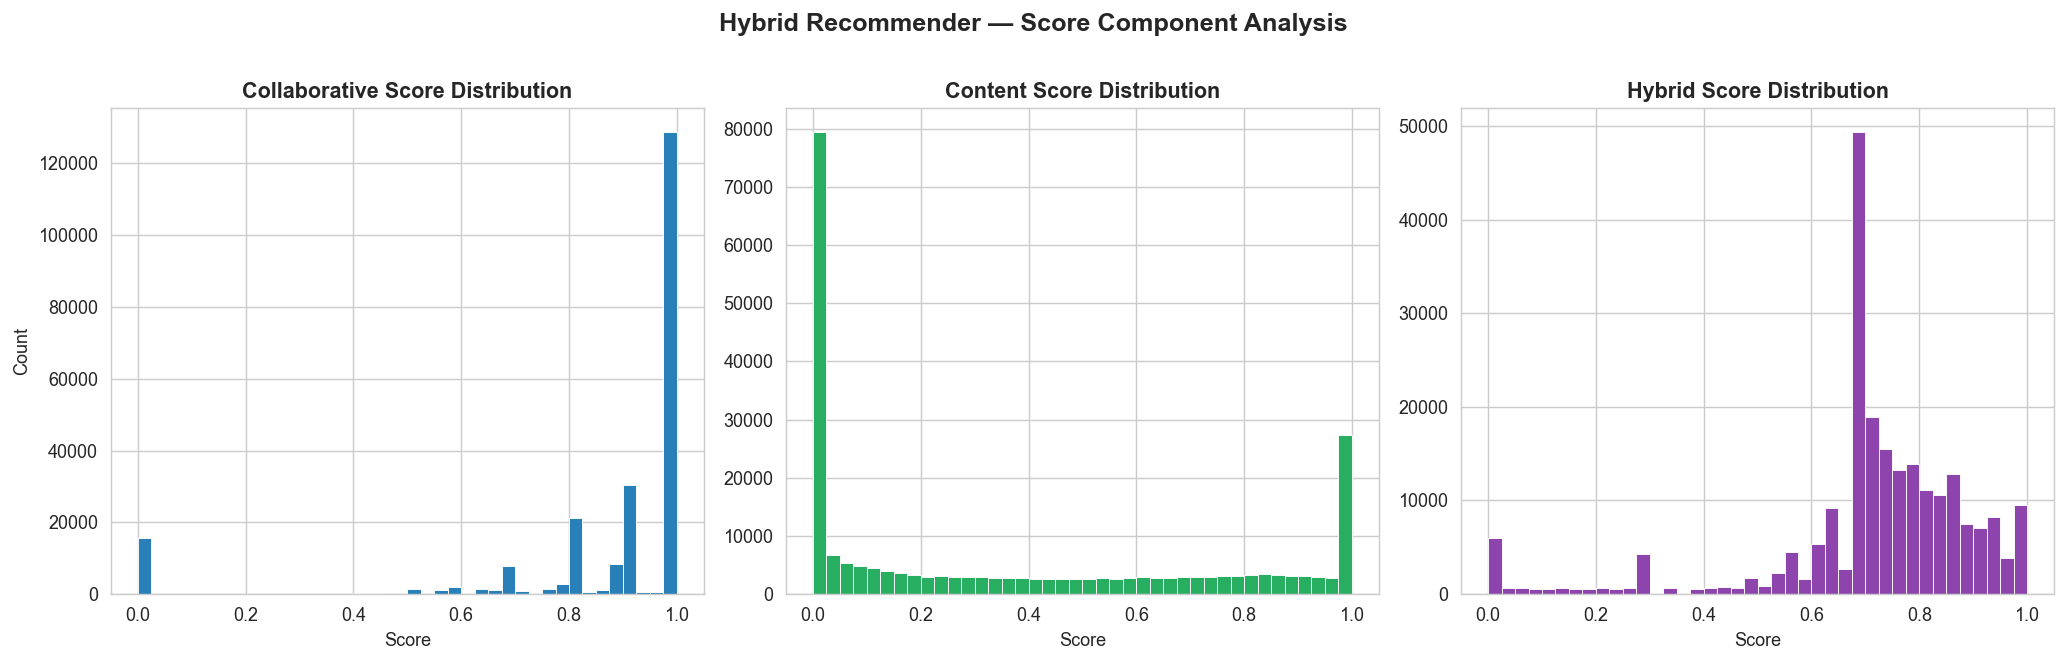

Mean collaborative score: 0.8619
Mean content score:       0.3678
Mean hybrid score:        0.7137


In [11]:
sample = hybrid_df.head(500)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(hybrid_df['Collaborative_Score'], bins=40,
             color='#2980b9', edgecolor='white', linewidth=0.5)
axes[0].set_title('Collaborative Score Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Score')
axes[0].set_ylabel('Count')

axes[1].hist(hybrid_df['Content_Score'], bins=40,
             color='#27ae60', edgecolor='white', linewidth=0.5)
axes[1].set_title('Content Score Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Score')

axes[2].hist(hybrid_df['Hybrid_Score'], bins=40,
             color='#8e44ad', edgecolor='white', linewidth=0.5)
axes[2].set_title('Hybrid Score Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Score')

plt.suptitle('Hybrid Recommender — Score Component Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../assets/hybrid_score_distribution.png', bbox_inches='tight')
plt.show()

print(f"Mean collaborative score: {hybrid_df['Collaborative_Score'].mean():.4f}")
print(f"Mean content score:       {hybrid_df['Content_Score'].mean():.4f}")
print(f"Mean hybrid score:        {hybrid_df['Hybrid_Score'].mean():.4f}")

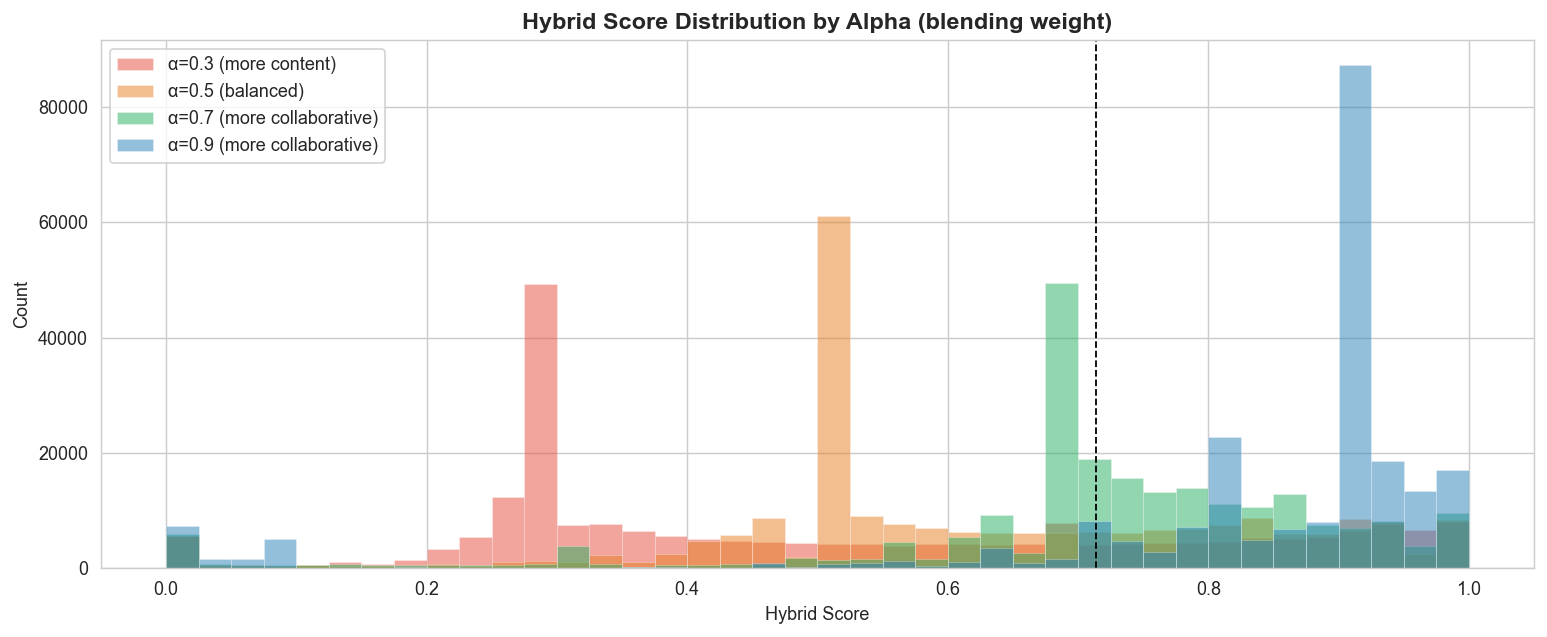

Alpha sensitivity analysis complete.
α=0.7 chosen as default — 70% collaborative, 30% content.
This can be tuned per user based on how many ratings they have.


In [12]:
# Show how changing alpha affects the hybrid score distribution
alphas = [0.3, 0.5, 0.7, 0.9]
colors = ['#e74c3c', '#e67e22', '#27ae60', '#2980b9']

fig, ax = plt.subplots(figsize=(12, 5))

for alpha, color in zip(alphas, colors):
    hybrid_scores = (
        alpha * hybrid_df['Collaborative_Score'] +
        (1 - alpha) * hybrid_df['Content_Score']
    )
    ax.hist(hybrid_scores, bins=40, alpha=0.5, color=color,
            label=f'α={alpha} ({"more content" if alpha < 0.5 else "more collaborative" if alpha > 0.5 else "balanced"})',
            edgecolor='white', linewidth=0.3)

ax.set_title('Hybrid Score Distribution by Alpha (blending weight)', fontsize=13, fontweight='bold')
ax.set_xlabel('Hybrid Score')
ax.set_ylabel('Count')
ax.legend(fontsize=10)
ax.axvline(hybrid_df['Hybrid_Score'].mean(), color='black', linestyle='--',
           linewidth=1, label='Current mean (α=0.7)')
plt.tight_layout()
plt.savefig('../assets/hybrid_alpha_sensitivity.png', bbox_inches='tight')
plt.show()

print("Alpha sensitivity analysis complete.")
print("α=0.7 chosen as default — 70% collaborative, 30% content.")
print("This can be tuned per user based on how many ratings they have.")

Computing overlap: 100%|██████████████████████████████████████████████████████████████████████████| 500/500 [01:50<00:00,  4.54it/s]


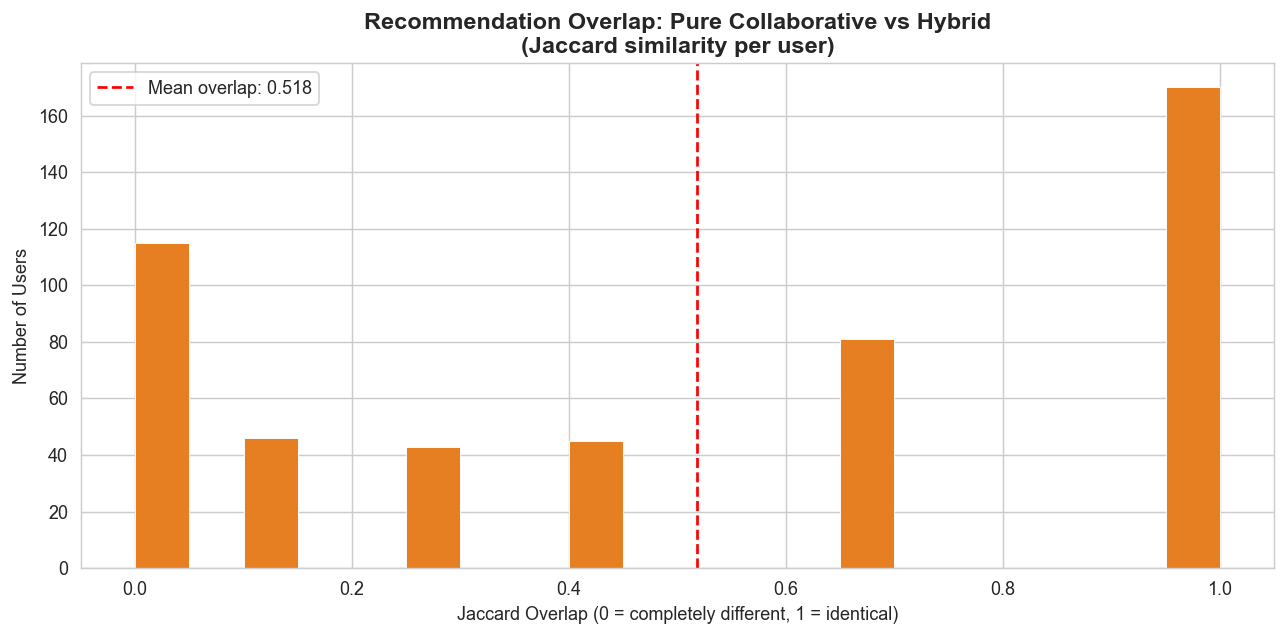

Mean Jaccard overlap: 0.5183
This means the hybrid recommender changes ~48.2% of recommendations
by incorporating content signals — not just a copy of collaborative filtering.


In [13]:
# Load pure collaborative recommendations for comparison
pure_df = pd.read_csv('../outputs/Book_recommendation.csv')

# Compare top book overlap between pure and hybrid for same users
common_users = set(pure_df['User_ID'].astype(str)) & set(hybrid_df['User_ID'].astype(str))
common_users = list(common_users)[:5000]

overlap_counts = []
for uid in tqdm(common_users[:500], desc="Computing overlap"):
    pure_books   = set(pure_df[pure_df['User_ID'].astype(str) == str(uid)]['Book_ID'].values)
    hybrid_books = set(hybrid_df[hybrid_df['User_ID'].astype(str) == str(uid)]['Book_ID'].values)
    if pure_books and hybrid_books:
        overlap = len(pure_books & hybrid_books) / len(pure_books | hybrid_books)
        overlap_counts.append(overlap)

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(overlap_counts, bins=20, color='#e67e22', edgecolor='white', linewidth=0.5)
ax.set_title('Recommendation Overlap: Pure Collaborative vs Hybrid\n(Jaccard similarity per user)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Jaccard Overlap (0 = completely different, 1 = identical)')
ax.set_ylabel('Number of Users')
ax.axvline(np.mean(overlap_counts), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean overlap: {np.mean(overlap_counts):.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('../assets/hybrid_vs_pure_overlap.png', bbox_inches='tight')
plt.show()

print(f"Mean Jaccard overlap: {np.mean(overlap_counts):.4f}")
print(f"This means the hybrid recommender changes ~{(1-np.mean(overlap_counts))*100:.1f}% of recommendations")
print("by incorporating content signals — not just a copy of collaborative filtering.")

In [15]:
# Pick a user who has recommendations in both systems
sample_uid = str(common_users[0])

print(f"User {sample_uid} — Side-by-side comparison")
print("=" * 80)

pure_recs   = pure_df[pure_df['User_ID'].astype(str) == sample_uid][['Book_Title', 'Recommendation_Score']].head(5)
hybrid_recs = hybrid_df[hybrid_df['User_ID'].astype(str) == sample_uid][
    ['Book_Title', 'Collaborative_Score', 'Content_Score', 'Hybrid_Score']].head(5)

print("\nPure Collaborative Filtering:")
print("-" * 40)
for _, row in pure_recs.iterrows():
    print(f"  {str(row['Book_Title'])[:55]:<55}  score: {row['Recommendation_Score']:.4f}")

print("\nHybrid Recommender (α=0.7):")
print("-" * 40)
for _, row in hybrid_recs.iterrows():
    print(f"  {str(row['Book_Title'])[:45]:<45}  "
          f"CF:{row['Collaborative_Score']:.3f}  "
          f"NLP:{row['Content_Score']:.3f}  "
          f"H:{row['Hybrid_Score']:.3f}")

User 126654 — Side-by-side comparison

Pure Collaborative Filtering:
----------------------------------------
  Unholy Love                                              score: 10.0000
  Mouse on the Mile (Green Mile S.)                        score: 10.0000
  Taming the Star Runner (Laurel-Leaf Contemporary Fictio  score: 10.0000
  Unknown                                                  score: 10.0000
  Unknown                                                  score: 10.0000

Hybrid Recommender (α=0.7):
----------------------------------------
  The Bridges of Madison County                  CF:0.900  NLP:0.552  H:0.796
  The Eurail Guide to World Train Travel 1997 (  CF:1.000  NLP:0.224  H:0.767
  An Illustrated Guide to Maori Art              CF:1.000  NLP:0.213  H:0.764
  Meeting the Whales: The Equinox Guide to Gian  CF:1.000  NLP:0.203  H:0.761
  Wind in the Willows                            CF:1.000  NLP:0.117  H:0.735


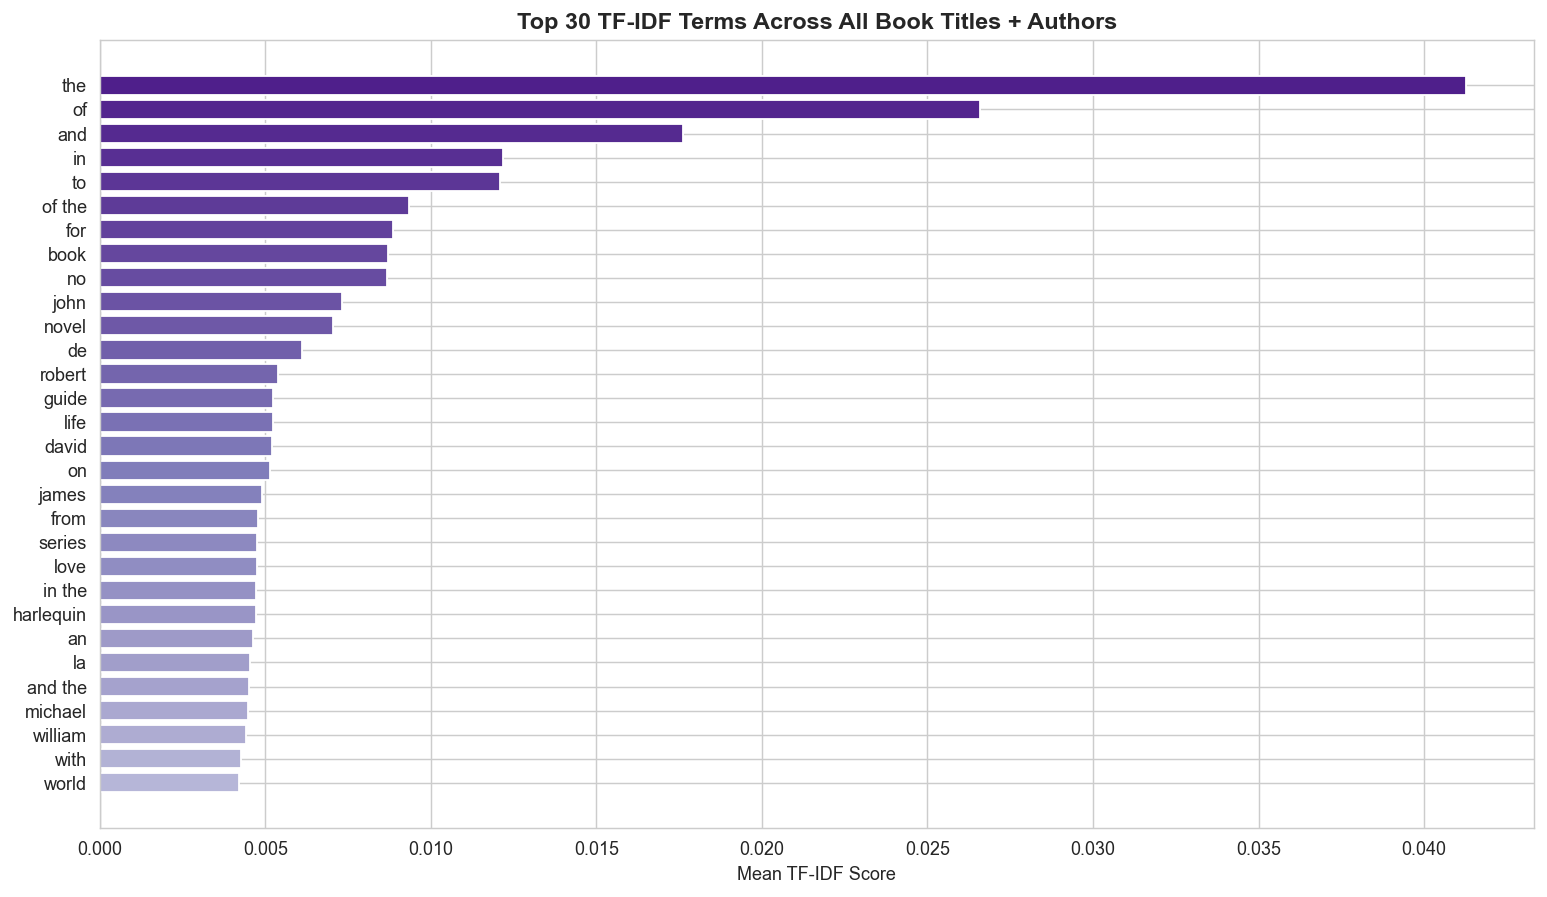

Top 10 most distinctive terms in the book corpus:
  the                       0.041256
  of                        0.026578
  and                       0.017616
  in                        0.012181
  to                        0.012097
  of the                    0.009342
  for                       0.008872
  book                      0.008704
  no                        0.008670
  john                      0.007328


In [16]:
# Show the most important vocabulary terms in the TF-IDF model
feature_names = tfidf.get_feature_names_out()
mean_tfidf    = np.asarray(tfidf_matrix.mean(axis=0)).flatten()
top_n         = 30
top_indices   = np.argsort(mean_tfidf)[-top_n:][::-1]
top_terms     = [(feature_names[i], mean_tfidf[i]) for i in top_indices]

terms_df = pd.DataFrame(top_terms, columns=['term', 'mean_tfidf'])

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(terms_df['term'][::-1], terms_df['mean_tfidf'][::-1],
        color=plt.cm.Purples(np.linspace(0.4, 0.9, top_n)))
ax.set_title('Top 30 TF-IDF Terms Across All Book Titles + Authors',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean TF-IDF Score')
plt.tight_layout()
plt.savefig('../assets/tfidf_top_terms.png', bbox_inches='tight')
plt.show()

print("Top 10 most distinctive terms in the book corpus:")
for term, score in top_terms[:10]:
    print(f"  {term:<25} {score:.6f}")

In [17]:
print("=" * 60)
print("  Addition 1 Complete — Hybrid Recommender System")
print("=" * 60)
print()
print("  What was built:")
print("  TF-IDF vectorizer on 271,378 book titles + authors")
print("  10,000-feature vocabulary with bigrams")
print("  Hybrid scoring: 70% collaborative + 30% content")
print()
print(f"  Users with hybrid recommendations: {hybrid_df['User_ID'].nunique():,}")
print(f"  Total recommendation rows:         {len(hybrid_df):,}")
print()
print("  Output files:")
print("    outputs/hybrid_recommendations.csv")
print()
print("  Charts saved:")
import os
charts = ['hybrid_score_distribution.png', 'hybrid_alpha_sensitivity.png',
          'hybrid_vs_pure_overlap.png', 'tfidf_top_terms.png']
for c in charts:
    path = f'../assets/{c}'
    if os.path.exists(path):
        print(f"    assets/{c}  ({os.path.getsize(path)/1024:.1f} KB)")

  Addition 1 Complete — Hybrid Recommender System

  What was built:
  TF-IDF vectorizer on 271,378 book titles + authors
  10,000-feature vocabulary with bigrams
  Hybrid scoring: 70% collaborative + 30% content

  Users with hybrid recommendations: 46,959
  Total recommendation rows:         229,666

  Output files:
    outputs/hybrid_recommendations.csv

  Charts saved:
    assets/hybrid_score_distribution.png  (47.5 KB)
    assets/hybrid_alpha_sensitivity.png  (41.5 KB)
    assets/hybrid_vs_pure_overlap.png  (40.3 KB)
    assets/tfidf_top_terms.png  (50.8 KB)
